In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [7]:
##Load Dataset
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [8]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
55546,47004,1.283418,0.354874,0.158519,0.607335,-0.186818,-0.865444,0.084609,-0.186195,0.042276,...,-0.310652,-0.887568,0.084508,-0.012270,0.267755,0.116476,-0.022729,0.027233,0.89,0.0
55547,47005,-0.969584,-0.514812,1.010076,-0.492493,-1.074442,0.812377,1.739011,0.069684,-0.741379,...,0.137958,-0.378729,0.989131,-0.311335,-0.302619,0.720578,-0.171671,0.034326,424.80,0.0
55548,47005,-0.448083,0.936043,1.308078,0.424255,0.141240,-0.224215,1.114183,-0.286478,-0.144553,...,0.084264,0.345878,-0.222427,0.052293,0.093368,-0.387899,-0.354380,-0.223041,55.75,0.0
55549,47005,0.616391,-0.770376,-0.306186,1.374006,-0.177289,0.186992,0.417697,0.073573,-0.009001,...,0.182098,-0.039148,-0.409170,-0.315762,0.626198,-0.254219,-0.042365,0.044234,293.00,0.0
55550,47005,-2.212795,0.701029,1.063799,1.449808,-1.045775,0.416184,-1.071689,-2.157124,0.014993,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df.shape

(55551, 31)

In [10]:
##chack class distribution
df['Class'].value_counts()

,count
Class,
0.0,55394
1.0,156


class = 0 is Legit transaction
Class = 1 is Fraud
Fraud cases are very rare(~0.17%)
This Dataset is highly unblanced

0 --> Normal Transaction

1 --> fraudulent transaction

In [11]:
# dataset informations
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55551 entries, 0 to 55550
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    55551 non-null  int64  
 1   V1      55551 non-null  float64
 2   V2      55551 non-null  float64
 3   V3      55551 non-null  float64
 4   V4      55551 non-null  float64
 5   V5      55551 non-null  float64
 6   V6      55551 non-null  float64
 7   V7      55551 non-null  float64
 8   V8      55551 non-null  float64
 9   V9      55551 non-null  float64
 10  V10     55551 non-null  float64
 11  V11     55551 non-null  float64
 12  V12     55551 non-null  float64
 13  V13     55551 non-null  float64
 14  V14     55551 non-null  float64
 15  V15     55550 non-null  float64
 16  V16     55550 non-null  float64
 17  V17     55550 non-null  float64
 18  V18     55550 non-null  float64
 19  V19     55550 non-null  float64
 20  V20     55550 non-null  float64
 21  V21     55550 non-null  float64
 22

In [12]:
#chack missing Value
df.isnull().sum().max()

1

In [13]:
# separating the data for analysis
legit = df[df.Class == 0]
fraud = df[df.Class == 1]

In [14]:
print(legit.shape)
print(fraud.shape)

(55394, 31)
(156, 31)


In [15]:
# statistical measures of the data
legit.Amount.describe()

,Amount
count,55394.000000
mean,94.703197
std,257.030241
min,0.000000
25%,7.680000
50%,25.790000
75%,86.907500
max,12910.930000


In [16]:
fraud.Amount.describe()

,Amount
count,156.000000
mean,95.758013
std,228.178528
min,0.000000
25%,1.000000
50%,4.930000
75%,99.990000
max,1809.680000


Under-Sampling

Build a sample dataset containing similar distribution of normal transactions and Fraudulent Transactions

Number of Fraudulent Transactions -- 94

In [17]:
legit_sample = legit.sample(n=94)

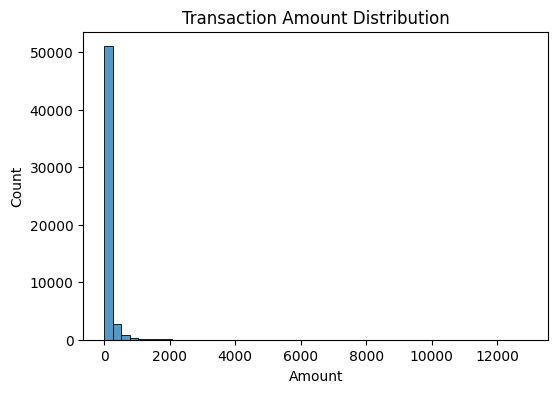

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

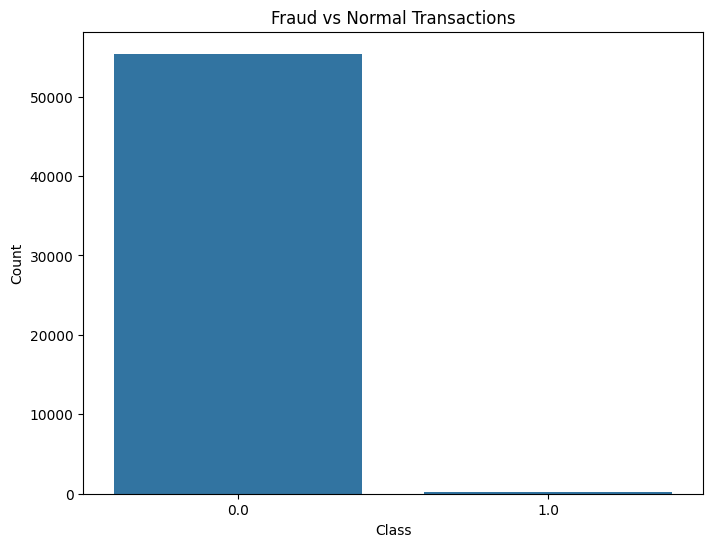

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Normal Transactions')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

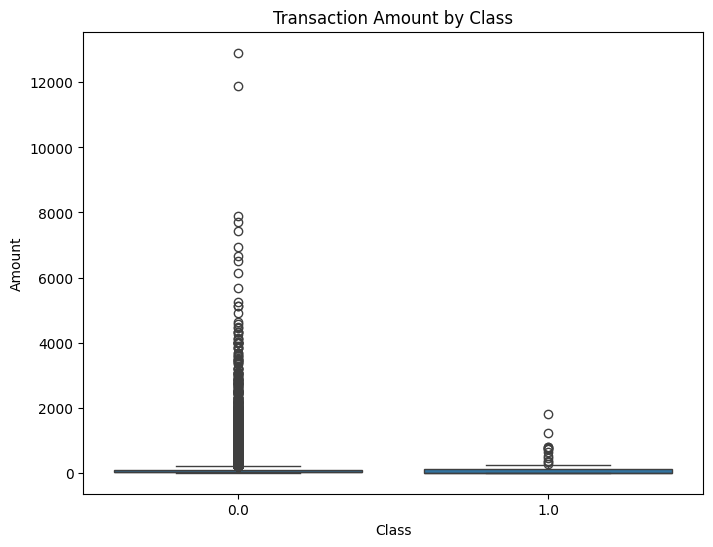

In [20]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class')
plt.show()

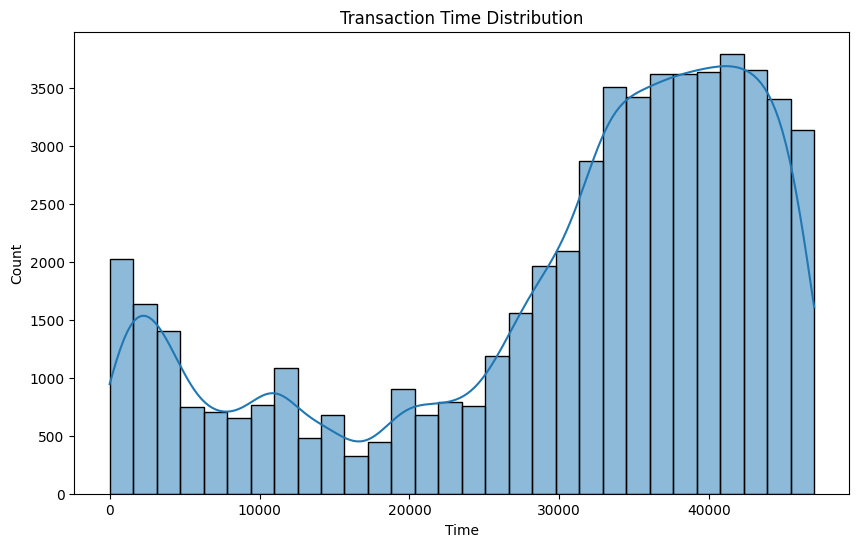

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(x='Time', data=df,kde=True , bins=30)
plt.title('Transaction Time Distribution')
plt.show()

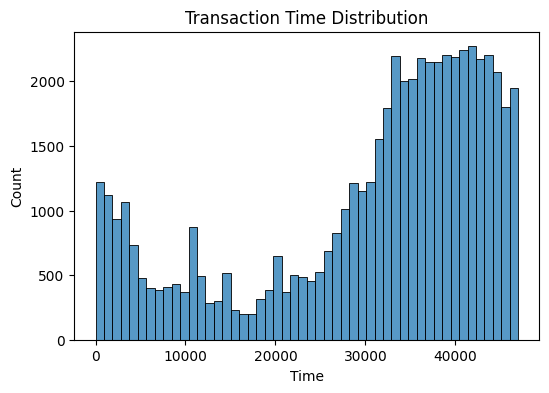

In [22]:
plt.figure(figsize=(6,4))
sns.histplot(df['Time'], bins=50)
plt.title("Transaction Time Distribution")
plt.show()

In [23]:
#Class Imbalance(SMOTE)
#feature Scaling Amount
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
df['Amount'] = sc.fit_transform(df[['Amount']])
df.drop(['Amount'], axis=1, inplace=True)

Concatenating two DataFrames

In [29]:
new_dataset = pd.concat([legit_sample, fraud], axis=0)

In [31]:
new_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
43644,41592,-0.763830,-0.885572,-0.276595,-2.398873,-3.299530,0.789485,3.144369,-0.604437,-0.307513,...,-0.339699,-0.241714,0.327958,0.097236,0.259976,0.088876,0.188125,-0.161950,690.64,0.0
3877,3426,-2.361982,0.291890,0.512896,-3.630647,-0.354358,-1.601132,1.213256,-0.689295,2.323985,...,-0.162219,-0.106989,-0.356261,0.429798,0.237146,-1.338556,-0.895729,0.696510,106.25,0.0
20558,31119,-0.764097,1.073745,0.763499,0.463888,0.552068,-0.239163,0.987080,-0.063711,-0.792705,...,0.173217,0.357614,-0.274708,0.007598,0.232804,-0.342054,-0.362448,0.018082,36.80,0.0
47441,43211,0.728971,-1.416395,0.885208,1.033421,-1.173113,1.252792,-0.728692,0.357070,-0.121029,...,-0.604535,-1.332002,-0.092578,-0.322353,0.257538,-0.530812,0.072199,0.060676,239.90,0.0
48177,43525,-1.199709,1.077646,-0.147173,0.051676,-1.806134,0.511443,1.063080,0.713482,-0.810670,...,0.002417,-0.155454,0.308146,0.006933,-0.555149,0.070405,-0.299163,-0.217162,301.83,0.0


In [32]:
new_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
52521,45501,1.001992,0.047938,-0.349002,1.493958,0.186939,0.190966,-0.001112,0.147140,0.580415,...,-0.334417,-1.014315,-0.128427,-0.946242,0.456090,-0.453206,0.046627,0.064698,105.99,1.0
52584,45541,-1.519244,2.308492,-1.503599,2.064101,-1.000845,-1.016897,-2.059731,-0.275166,-1.562206,...,1.307871,0.102826,-0.017746,0.149696,-0.096602,-0.369115,-0.019244,-0.208319,1.00,1.0
53591,46057,-1.309441,1.786495,-1.371070,1.214335,-0.336642,-1.390120,-1.709109,0.667748,-1.699809,...,0.533521,-0.022180,-0.299556,-0.226416,0.364360,-0.475102,0.571426,0.293426,1.00,1.0
53794,46149,-1.346509,2.132431,-1.854355,2.116998,-1.070378,-1.092671,-2.230986,1.036425,-1.895516,...,0.609508,0.202874,-0.060791,-0.186733,-0.017401,-0.283751,0.395451,0.233139,1.00,1.0
55401,46925,-0.481531,1.059542,0.647117,0.905586,0.819368,-0.091184,0.504135,0.161064,-0.765054,...,0.070633,0.192491,-0.174659,-0.438908,0.239259,-0.217823,-0.072852,0.010463,1.00,1.0


In [33]:
new_dataset['Class'].value_counts()

,count
Class,
1.0,156
0.0,94


In [34]:
new_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0.0,31509.723404,-0.120420,-0.098164,0.697199,0.134685,-0.228161,0.127128,-0.087361,0.017611,0.232833,...,-0.001699,-0.016053,-0.099767,-0.008828,-0.038382,0.199681,-0.018457,0.043387,-0.015323,80.999894
1.0,27835.794872,-7.345427,5.255872,-9.922599,5.709553,-5.426307,-2.204159,-7.736462,3.560034,-3.453697,...,0.449731,0.881689,-0.211806,-0.275513,-0.088146,0.239724,0.127377,0.580843,0.031086,95.758013


Splitting the data into Features & Targets

In [35]:
X = new_dataset.drop(columns='Class', axis=1)
Y = new_dataset['Class']

In [36]:
print(X)

        Time        V1        V2        V3        V4        V5        V6  \
43644  41592 -0.763830 -0.885572 -0.276595 -2.398873 -3.299530  0.789485   
3877    3426 -2.361982  0.291890  0.512896 -3.630647 -0.354358 -1.601132   
20558  31119 -0.764097  1.073745  0.763499  0.463888  0.552068 -0.239163   
47441  43211  0.728971 -1.416395  0.885208  1.033421 -1.173113  1.252792   
48177  43525 -1.199709  1.077646 -0.147173  0.051676 -1.806134  0.511443   
...      ...       ...       ...       ...       ...       ...       ...   
52521  45501  1.001992  0.047938 -0.349002  1.493958  0.186939  0.190966   
52584  45541 -1.519244  2.308492 -1.503599  2.064101 -1.000845 -1.016897   
53591  46057 -1.309441  1.786495 -1.371070  1.214335 -0.336642 -1.390120   
53794  46149 -1.346509  2.132431 -1.854355  2.116998 -1.070378 -1.092671   
55401  46925 -0.481531  1.059542  0.647117  0.905586  0.819368 -0.091184   

             V7        V8        V9  ...       V20       V21       V22  \
43644  3.1443

In [37]:
print(Y)

43644    0.0
3877     0.0
20558    0.0
47441    0.0
48177    0.0
        ... 
52521    1.0
52584    1.0
53591    1.0
53794    1.0
55401    1.0
Name: Class, Length: 250, dtype: float64


Split the data into Training data & Testing Data

In [38]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [39]:
print(X.shape, X_train.shape, X_test.shape)

(250, 30) (200, 30) (50, 30)


In [40]:
#Apply SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, Y_train_res = smote.fit_resample(X_train, Y_train)

Y_train_res.value_counts()


,count
Class,
1.0,125
0.0,125


SMOTE creates synthetic fraud samples to balance data.

Model Training

Logistic Regression

In [41]:
model = LogisticRegression()

In [42]:
# training the Logistic Regression Model with Training Data
model.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [43]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, Y_train_res)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
#XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    use_label_encoder=False
)

xgb.fit(X_train_res, Y_train_res)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:18:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model Evaluation

Accuracy Score

In [45]:
# accuracy on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [46]:
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  0.96


In [47]:
# accuracy on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [48]:
print('Accuracy score on Test Data : ', test_data_accuracy)

Accuracy score on Test Data :  0.96


In [49]:
 from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


In [50]:
print(confusion_matrix(Y_test, X_test_prediction))

[[17  2]
 [ 0 31]]


In [51]:
print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

         0.0       1.00      0.89      0.94        19
         1.0       0.94      1.00      0.97        31

    accuracy                           0.96        50
   macro avg       0.97      0.95      0.96        50
weighted avg       0.96      0.96      0.96        50



In [52]:
print(roc_auc_score(Y_test, X_test_prediction))

0.9473684210526316
